<a href="https://colab.research.google.com/github/honeylouluzon/Guided-Project-AI-ML-DataScience/blob/main/Predicting_Listing_Gains_in_the_Indian_IPO_Market_Using_Tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Guided Project: Predicting Listing Gains in the Indian IPO Market Using Tensorflow

##Introduction

When a company goes public, they set an initial price for their stock (called the issue price). On the day the stock starts trading publicly, the market decides what it's actually worth. If investors are excited about the company, the stock price might jump up from that initial price, which is a listing gain. If investors aren't too sure, the price might stay flat or even drop. In this project, the trained model is aimed to predict whether an IPO will be a winner (positive listing gains) or not.

##Data Dictionary

The dataset contains the following columns:

1. **Date**: date when the IPO was listed
2. **IPOName**: name of the IPO
3. **Issue_Size**: size of the IPO issue, in INR Crores
4. **Subscription_QIB**: number of times the IPO was subscribed by QIB (Qualified Institutional Buyer) investors
5. **Subscription_HNI**: number of times the IPO was subscribed by HNI (High Networth Individual) investors
6. **Subscription_RII**: number of times the IPO was subscribed by RII (Retail Individual Investors)
7. **Subscription_Total**: total number of times the IPO was subscribed overall
8. **Issue_Price**: the price in INR at which the IPO was issued
9. **Listing_Gains_Percent**: percentage gain in the listing price over the issue price (this becomes our target!)


##Imports

In [ ]:
#Needed imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, r2_score
import copy

#Needed Imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


##Dataset

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Indian_IPO_Market_Data.csv")

##Data Exploration

###Initial Summary

In [ ]:
data.head()

,Date,IPOName,Issue_Size,Subscription_QIB,Subscription_HNI,Subscription_RII,Subscription_Total,Issue_Price,Listing_Gains_Percent
0,03/02/10,Infinite Comp,189.80,48.44,106.02,11.08,43.22,165,11.82
1,08/02/10,Jubilant Food,328.70,59.39,51.95,3.79,31.11,145,-84.21
2,15/02/10,Syncom Health,56.25,0.99,16.60,6.25,5.17,75,17.13
3,15/02/10,Vascon Engineer,199.80,1.12,3.65,0.62,1.22,165,-11.28
4,19/02/10,Thangamayil,0.00,0.52,1.52,2.26,1.12,75,-5.20


In [ ]:
data.tail()

,Date,IPOName,Issue_Size,Subscription_QIB,Subscription_HNI,Subscription_RII,Subscription_Total,Issue_Price,Listing_Gains_Percent
314,26/08/22,Syrma SGS,840.13,42.42,7.13,2.84,15.59,220,42.30
315,06/09/22,Dreamfolks Serv,562.10,27.48,14.18,24.19,23.25,326,41.92
316,15/09/22,TMB,792.00,0.51,1.77,3.44,1.39,525,-3.15
317,26/09/22,Harsha Engineer,755.00,113.82,40.36,12.44,47.19,330,47.24
318,17/10/22,Electronics Mar,500.00,58.81,15.39,8.27,24.23,59,43.14


In [ ]:
print(f"Shape: {data.shape}")
print(f"Info: {data.info()}")

Shape: (319, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   319 non-null    object 
 1   IPOName                319 non-null    object 
 2   Issue_Size             319 non-null    float64
 3   Subscription_QIB       319 non-null    float64
 4   Subscription_HNI       319 non-null    float64
 5   Subscription_RII       319 non-null    float64
 6   Subscription_Total     319 non-null    float64
 7   Issue_Price            319 non-null    int64  
 8   Listing_Gains_Percent  319 non-null    float64
dtypes: float64(6), int64(1), object(2)
memory usage: 22.6+ KB
Info: None


In [ ]:
data.describe()

,Issue_Size,Subscription_QIB,Subscription_HNI,Subscription_RII,Subscription_Total,Issue_Price,Listing_Gains_Percent
count,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000
mean,1192.859969,25.684138,70.091379,8.561599,27.447147,375.128527,4.742696
std,2384.643786,40.716782,142.454416,14.508670,48.772203,353.897614,47.650946
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-97.150000
25%,169.005000,1.150000,1.255000,1.275000,1.645000,119.000000,-11.555000
50%,496.250000,4.940000,5.070000,3.420000,4.930000,250.000000,1.810000
75%,1100.000000,34.635000,62.095000,8.605000,33.395000,536.000000,25.310000
max,21000.000000,215.450000,958.070000,119.440000,326.490000,2150.000000,270.400000


###Profitable IPO Count

In [ ]:
Listing_Gains_Profit =  data["Listing_Gains_Percent"].apply(lambda x: 1 if x>=0 else 0)

In [ ]:
Listing_Gains_Profit

,Listing_Gains_Percent
0,1
1,0
2,1
3,0
4,0
...,...
314,1
315,1
316,0
317,1


In [ ]:
Listing_Gains_Profit.value_counts()

,count
Listing_Gains_Percent,
1,176
0,143


**Observation 1:**
The data shows that only 55% of IPO are profitable.



##Data Cleaning

In [ ]:
#Column
#remove white spaces
data.columns = data.columns.str.strip()
print(data.columns.tolist())

['Date', 'IPOName', 'Issue_Size', 'Subscription_QIB', 'Subscription_HNI', 'Subscription_RII', 'Subscription_Total', 'Issue_Price', 'Listing_Gains_Percent']


In [ ]:
#Check Index
print(data.index)
print(data.columns)

#Remove Index incase can't drop column
#data.reset_index(drop=True, inplace=True)

#Set Index
#data = data.set_index('col_name')


RangeIndex(start=0, stop=319, step=1)
Index(['Date', 'IPOName', 'Issue_Size', 'Subscription_QIB', 'Subscription_HNI',
       'Subscription_RII', 'Subscription_Total', 'Issue_Price',
       'Listing_Gains_Percent'],
      dtype='object')


##Modeling Preparation

In [ ]:
IPO_data=pd.DataFrame(data)

toDrop=['Date', 'IPOName']
IPO_data=IPO_data.drop(toDrop,axis=1)
IPO_data['Listing_Gains_Profit'] = Listing_Gains_Profit
IPO_data.head()

,Issue_Size,Subscription_QIB,Subscription_HNI,Subscription_RII,Subscription_Total,Issue_Price,Listing_Gains_Percent,Listing_Gains_Profit
0,189.80,48.44,106.02,11.08,43.22,165,11.82,1
1,328.70,59.39,51.95,3.79,31.11,145,-84.21,0
2,56.25,0.99,16.60,6.25,5.17,75,17.13,1
3,199.80,1.12,3.65,0.62,1.22,165,-11.28,0
4,0.00,0.52,1.52,2.26,1.12,75,-5.20,0


##EDA: Exploratory Data Analysis

###Distribution Plot

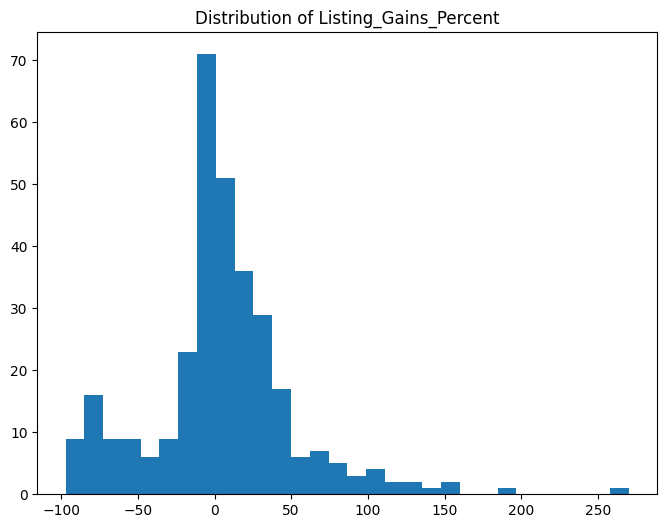

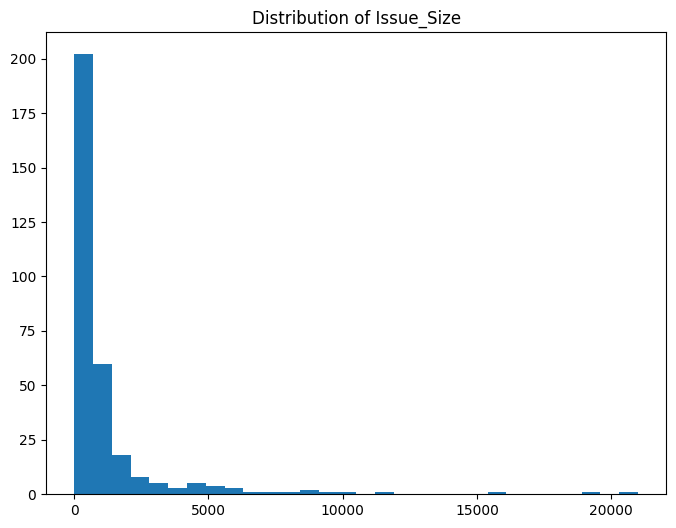

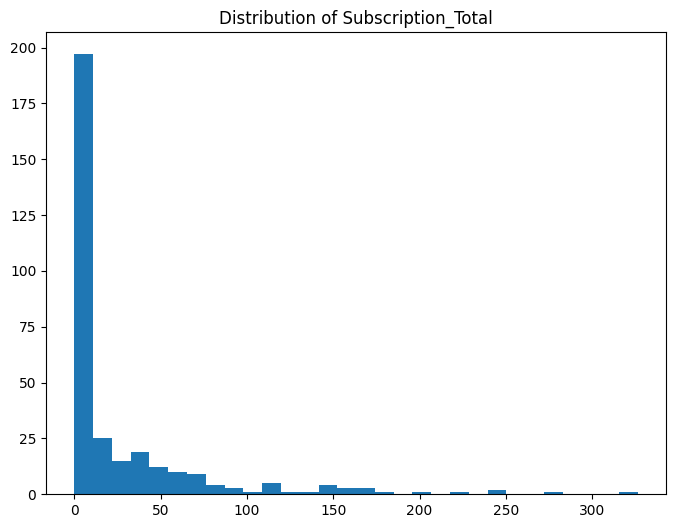

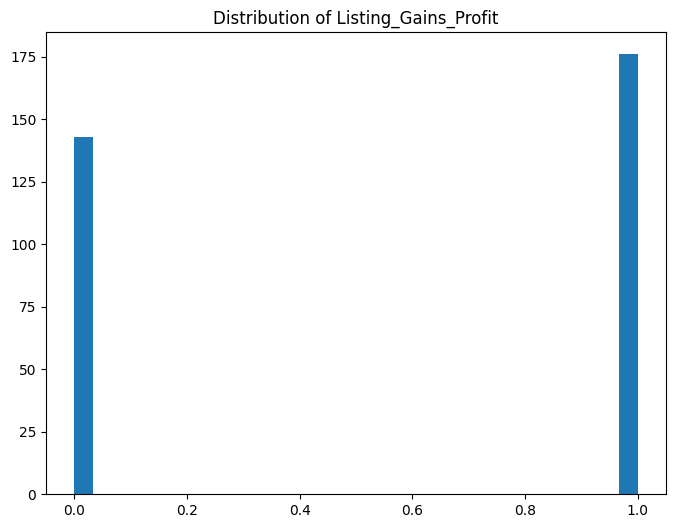

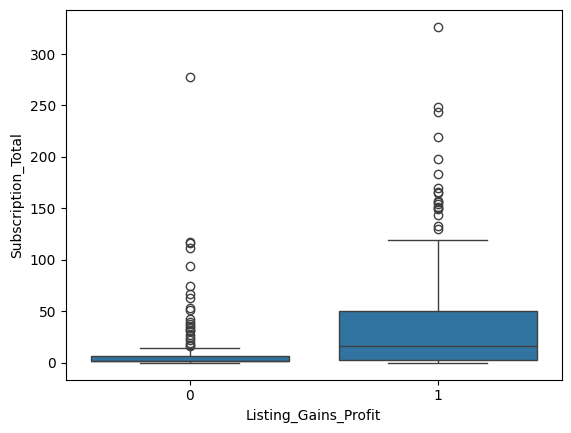

<function matplotlib.pyplot.show(close=None, block=None)>

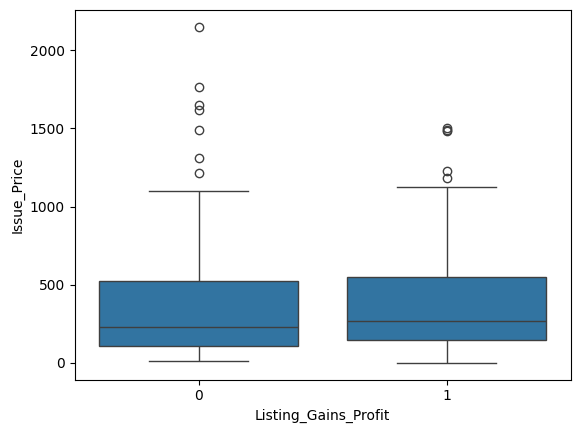

In [ ]:
# For single variables
cols=['Listing_Gains_Percent', 'Issue_Size', 'Subscription_Total', 'Listing_Gains_Profit']
for col in cols:
  plt.figure(figsize=(8, 6))
  plt.hist(IPO_data[col], bins=30)
  plt.title(f"Distribution of {col}")
  plt.show()

# For comparing groups
sns.boxplot(data=IPO_data, x='Listing_Gains_Profit', y='Subscription_Total', showfliers=True)
plt.show()
sns.boxplot(data=IPO_data, x='Listing_Gains_Profit', y='Issue_Price')
plt.show

###Correlation Analysis

<Axes: >

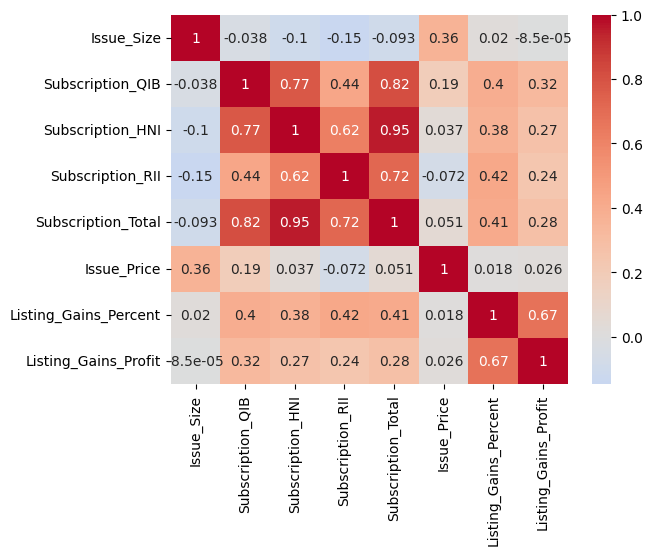

In [ ]:
# Correlation matrix
correlation_matrix = IPO_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

**Observation**:
Listing Gains Profit shows a strong positive correlation with Subscription, suggesting that subscription levels may significantly influence IPO success. Additionally, Issue Size appears to be positively correlated with Issue Price, indicating that larger issues tend to have higher issue prices. While Issue Size itself exhibits a very weak correlation with Listing Gains Profit, Issue Price shows a correlation with Subscription_QIB, which may indirectly contribute to higher IPO profitability.

###Target Relationships

In [ ]:
# Grouping by target to see differences
profitable_group = IPO_data[IPO_data['Listing_Gains_Profit'] == 1]
not_profitable_group = IPO_data[IPO_data['Listing_Gains_Profit'] == 0]
#print(f'PROFITABLE:\n{profitable_group}')

##Data Splitting and Scaling

In [ ]:
IPO_data=IPO_data.drop(["Listing_Gains_Percent"], axis=1)
X = IPO_data.drop(["Listing_Gains_Profit"], axis=1)
y = IPO_data["Listing_Gains_Profit"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=417)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.20*X.shape[0]/X_train.shape[0], random_state=417)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.fit_transform(X_val)
X_test_scaled = scaler.fit_transform(X_test)


In [ ]:
print(f"Train X Set: {X_train_scaled.shape}")
print(f"Validation X Set: {X_val_scaled.shape}")
print(f"Test X Set: {X_test_scaled.shape}")

Train X Set: (191, 6)
Validation X Set: (64, 6)
Test X Set: (64, 6)


##Model Architecture Design

In [ ]:
#Defining the model
model = tf.keras.Sequential(name='sequential')


In [ ]:
#Defining the layer of the model
model.add(tf.keras.layers.Dense(32, input_shape=(X_train.shape[1],), activation='relu'))
model.add(tf.keras.layers.Dense(16, activation='relu'))
model.add(tf.keras.layers.Dense(8, activation='relu'))
model.add(tf.keras.layers.Dense(4, activation='relu'))
model.add(tf.keras.layers.Dense(1))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

##Compile the Model

We need to compile the model before it can be trained. Compiling a model requires us to specify an optimizer and a loss function.

###Optimizer

We will use Adam for this model. **Adam** is an extension of the well-known stochastic gradient descent (SGD) algorithm. **SGD** is a simple and efficient approach to minimizing an objective function that has smooth, bounded gradients. However, SGD can be difficult to use when training deep neural networks because it requires careful tuning of the learning rate.

In [ ]:
#optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
#merged to compile

###Loss Function

In [ ]:
model.compile(loss='binary_crossentropy', metrics=['accuracy'], optimizer='adam')

##Train the Model on Train and Test Set

In [ ]:
X_train_casted = X_train.astype(np.float32)
y_train_casted = y_train.astype(np.float32)

model.fit(X_train_casted, y_train_casted, epochs=150, verbose=0)

##Evaluate the Model

In [ ]:
model.evaluate(X_train_casted, y_train_casted)




6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4555 - loss: 8.7763  


[8.776345252990723, 0.4554973840713501]

In [ ]:
pred_train = model.predict(X_train_casted)
r_squared_value = r2_score(y_train_casted, pred_train)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


NameError: name 'r2_score' is not defined

##Visualize the Result

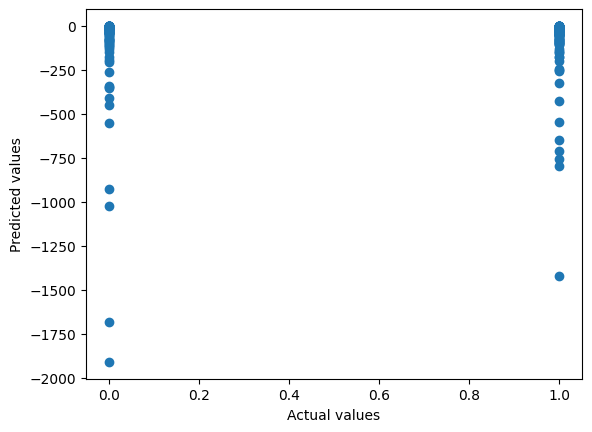

In [ ]:
plt.scatter(y_train, pred_train)
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.show()